ML – MIDTERM EXAM (100 Marks)

- Name: Subrata Saha
- Date: 10/12/2025

This notebook is your **single submission file** for the Midterm.

- **Total marks:** 100  
  - Section A: 40 marks  
  - Section B: 60 marks  
- Answer **all questions** in this notebook.  
- Do **not** create a separate PDF.  
- Use clear headings, code, and explanations.

- Run all cells before submitting so all outputs are visible.
- Set the Colab file's shareable link to ‘Anyone with the link’ and ‘View’ access, then submit it in the Phitron Assignment module's Assignment submission section.

In [216]:
# Common imports for Section B (run once)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['axes.grid'] = True

---

## SECTION A – Short Application Questions (40 Marks)

Write your answers in the provided **answer cells** in this notebook. Use text, formulas, and short reasoning.

Marks for each question are clearly mentioned.

---

### Q1. Descriptive Statistics and Distributions (15 marks)

A dataset of monthly customer spending (in dollars) is:

`[30, 35, 32, 34, 33, 500, 31, 34, 32, 33]`

1. Compute the **median** and **IQR**. Show your working clearly.  
2. Use the **IQR rule** to check if 500 is an outlier. Show your steps and the fences.  
3. Explain in 3 to 5 sentences why **median + IQR** may be better than **mean + standard deviation** for this dataset.

Write your full answer in the cell below.


#### Q1 Answer (Student)

**Ans 1.1: Median:**

sorting the data: [30, 31, 32, 32, 33, 33, 34, 34, 35, 500], total=10

as total numbers are even, median is the avg of 5th and 6th value.

median= (33+33)/2 = 33

**IQR:**
Q1 = median of first 5 values. which is 32

Q3= median of the last 5 values, which is 34

IQR= Q3-Q1=34-32=2

**Ans 1.2: Outlier:**

lower fence: Q1-1.5 x IQR = 32-1.5 x 2 = 29

upper fence: Q3+1.5 x IQR= 34+1.5 x 2 = 37

as 500 is very much grater than 37, it is considered as an outlier.

**Ans 1.3: why:**

As most of the data are in 30-35 range except an extreme outlier 500, which can affect mean and SD largely. the mean will be very large because of the 500. on the other hand, median and IQR are not affected by the outlier. so, for this dataset, median and IQR can give more reliable outlook of the dataset for further processing.

In [217]:
# Optional helper code for Q1 (not required)
data_q1 = [30, 35, 32, 34, 33, 500, 31, 34, 32, 33]
data_q1

[30, 35, 32, 34, 33, 500, 31, 34, 32, 33]

### Q2. Bayes and Probability in ML (10 marks)

A disease affects **1 percent** of people.  
A test has:  
- Sensitivity: **90 percent**  
- Specificity: **92 percent**  

A random person tests positive.

1. Compute the **positive predictive value (PPV)** using Bayes theorem. Show all steps with probabilities.  
2. If prevalence rises to **20 percent**, explain in 3 to 4 sentences whether PPV increases or decreases and why. You may refer to the Bayes formula in words.

Write your full answer in the cell below.



**Ans 2.1: PPV:**

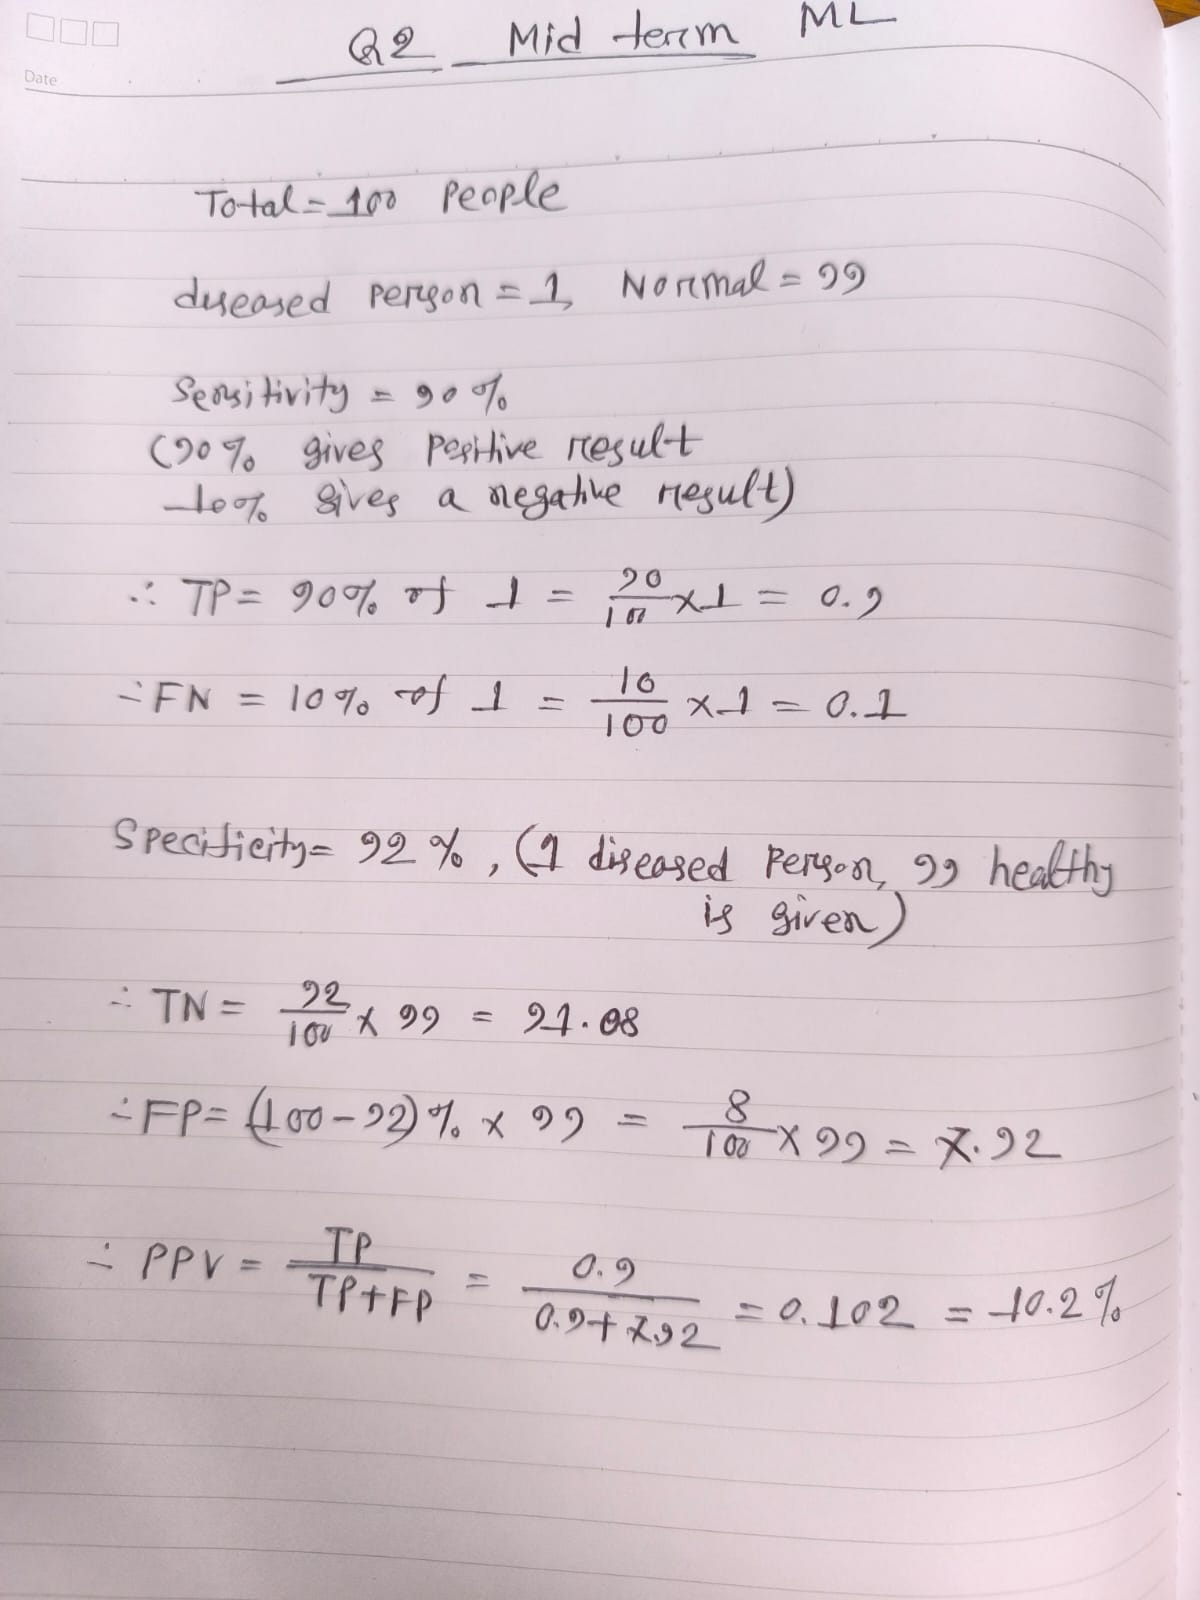


**Ans 2.2:**

If prevalence increases to 20%,PPV will increase too. As PPV depends heavily on TP so When more people in the population are truly sick, the number of true positives increases and FP becomes lower or stays almost the same.


### Q3. ML Pipeline Thinking (15 marks)

Columns in a new dataset:

- `age` (numeric)  
- `region` (categorical with 7 levels)  
- `daily_clicks` (numeric)  
- `premium_user` (0 or 1 target)

1. Identify the **type of ML task**. (1 or 2 lines)  
2. List **four preprocessing steps** that would be reasonable for this dataset. (bullet points are fine)  
3. In one short paragraph (6 to 8 sentences), describe the **end to end ML pipeline** you would follow for this problem, from raw data to model evaluation.

Write your full answer in the cell below.


#### Q3 Answer (Student)

**Ans 3.1: type of ML task:** As the task of the ML algorithm will be to predict "premium user" or "not a premium user", this is a binary classification task.

**Ans 3.2: four preprocessing steps:**
1. check for missing values and solve them if any. such as, replace the age with the average or median value. replace region with the most frequent value.
2. remove outliers if there are any. or if the dataset is not very large outliers can be clipped.
3. encode categorial column such as "region".
4. scaling will applied because all columns will not be in the same scale.

**Ans 3.3:  end to end ML pipeline:**

First of all, the dataset will be loaded and check for the basic summary statistics.Then check for any missing values and either delete them (if there are few missing values) or replace with average, median or mode value, depending on the data. Then encode the categorial columns. After the pre processing, dataset will be split into traning and test sets. Later, appropriate ML model will be applied for this classification algorithm such as decision tree . Finally, evaluation will be done using accuracy score, precision, recall etc.

---

## SECTION B – Applied Coding Problems (60 Marks)

Answer **all three questions** in this section.

- Write clean, commented code.  
- After each main step, add a short markdown explanation of what you did and what you observe.  
- Make sure all plots are visible in the notebook.

Marks for each question are clearly mentioned.

---

### Q4. Applied EDA and Preprocessing (20 marks)

We work with the following dataset:

```python
import pandas as pd

df = pd.DataFrame({
    "age": [25, 30, None, 22, 45, 52, None],
    "region": ["north","south","north","east","west","west","south"],
    "purchases": [3, 10, 5, None, 20, 18, 9],
    "premium_user": [0,1,0,0,1,1,0]
})
```

**Tasks (20 marks total):**

1. **Compact EDA using pandas** (6 marks)  
   - Show missing value summary for each column.  
   - Show number of unique values per column.  
   - Show correlation among numeric columns.  
   - Plot:  
     - A histogram of `purchases`.  
     - A bar chart for `region` frequency.

2. **Preprocess the dataset using sklearn plus pandas** (9 marks)  
   - Impute `age` with **median**.  
   - Impute `purchases` with **mean**.  
   - One hot encode `region`.  
   - Scale all numeric columns using **RobustScaler**.

3. **Create one domain driven feature** (3 marks)  
   - Example ideas: `high_spender` based on `purchases`, or `age_group` bins, or an interaction like `age * purchases`.

4. Show the **final transformed dataframe** ready for model training. (2 marks)

Use short explanations in markdown to describe each main block of code.


In [218]:
# Q4 – Student Answer

# Step 1: Create the dataframe
df = pd.DataFrame({
    "age": [25, 30, None, 22, 45, 52, None],
    "region": ["north","south","north","east","west","west","south"],
    "purchases": [3, 10, 5, None, 20, 18, 9],
    "premium_user": [0,1,0,0,1,1,0]
})

df

,age,region,purchases,premium_user
0,25.0,north,3.0,0
1,30.0,south,10.0,1
2,NaN,north,5.0,0
3,22.0,east,NaN,0
4,45.0,west,20.0,1
5,52.0,west,18.0,1
6,NaN,south,9.0,0


*_Use* additional code cells below for EDA, preprocessing, feature engineering, and final dataframe. Add brief explanations in markdown between code blocks._

**Ans 4.1: Compact EDA:**

missing sumnmary:
age             2
region          0
purchases       1
premium_user    0
dtype: int64 

Unique values:
age             5
region          4
purchases       6
premium_user    2
dtype: int64 

correlation:



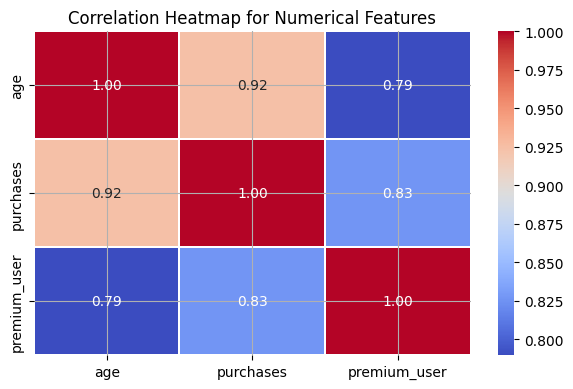

,premium_user
premium_user,1.000000
purchases,0.825860
age,0.789534


In [219]:
import seaborn as sns

# # Show missing value summary for each column.
print("missing sumnmary:")
print(df.isna().sum(),"\n")

# Show number of unique values per column.
print("Unique values:")
print(df.nunique(),"\n")

# Show correlation among numeric columns.
print("correlation:\n")
numeric_cols=["age", "purchases"]
target_col="premium_user"
corr_matrix = df[numeric_cols + [target_col]].corr()

# plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm",fmt=".2f", linewidths=0.1)
plt.title("Correlation Heatmap for Numerical Features")
plt.tight_layout()
plt.show()

display(corr_matrix[target_col].sort_values(ascending=False))

Plots:



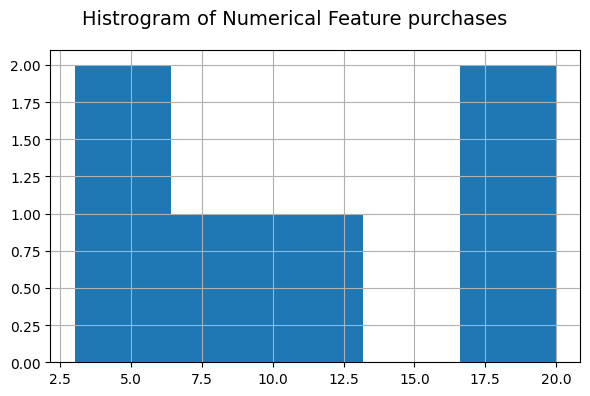

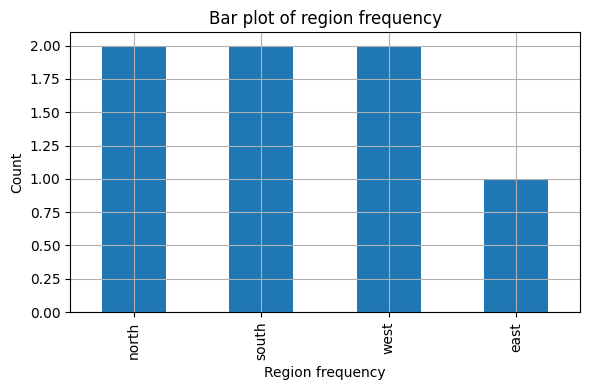

In [220]:
# Plot
print("Plots:\n")
# A histogram of purchases.
df["purchases"].hist(bins=5, figsize=(6,4))
plt.suptitle("Histrogram of Numerical Feature purchases", fontsize = 14)
plt.tight_layout()
plt.show()

# A bar chart for region frequency.
plt.figure(figsize=(6,4))
df["region"].value_counts().plot(kind="bar")
plt.title(f"Bar plot of region frequency")
plt.xlabel("Region frequency")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

**explanation**

- age and purchases have missing values.
- All columns have more than 1 unique value.
- premium_user has the highest correlation with purchases.
- age also has good correlation with purchases.
- purchases has highest values in the range 2.7 to 5.5 and approx. 17 to 20.
- north, south, and west have the highest frequency of 2, and east has the lowest frequency.

**Ans 4.2: Preprocess the dataset:**

In [221]:
# df.head()

In [222]:
# Impute "age" with median.
df["age"] = df["age"].fillna(df["age"].median())

# Impute `purchases` with mean.
df["purchases"] = df["purchases"].fillna(df["purchases"].mean())

# One hot encode `region`.
df = pd.get_dummies(df, columns=["region"], dtype=int)
df_domain=df.copy()

print("before scaling\n")
display(df_domain.head(10))
print("\n")

# display(df.head(10))
# Scale all numeric columns using RobustScaler
numeric_cols = ["age", "purchases"]
scaler = RobustScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("after scaling\n")
df.head(10)


before scaling



,age,purchases,premium_user,region_east,region_north,region_south,region_west
0,25.0,3.000000,0,0,1,0,0
1,30.0,10.000000,1,0,0,1,0
2,30.0,5.000000,0,0,1,0,0
3,22.0,10.833333,0,1,0,0,0
4,45.0,20.000000,1,0,0,0,1
5,52.0,18.000000,1,0,0,0,1
6,30.0,9.000000,0,0,0,1,0




after scaling



,age,purchases,premium_user,region_east,region_north,region_south,region_west
0,-0.5,-0.943820,0,0,1,0,0
1,0.0,0.000000,1,0,0,1,0
2,0.0,-0.674157,0,0,1,0,0
3,-0.8,0.112360,0,1,0,0,0
4,1.5,1.348315,1,0,0,0,1
5,2.2,1.078652,1,0,0,0,1
6,0.0,-0.134831,0,0,0,1,0


**explanation**

- missing value in age is replaced with the median value 30.
- in purchase missing value is replaced with the average value 10.83.
- after one hot encoding, there are 4 new feature columns added, replacing the region column.
- scaling is applied to age and purchases columns.

**Ans 4.3: domain driven feature:**

In [223]:
df_domain.head(10)

,age,purchases,premium_user,region_east,region_north,region_south,region_west
0,25.0,3.000000,0,0,1,0,0
1,30.0,10.000000,1,0,0,1,0
2,30.0,5.000000,0,0,1,0,0
3,22.0,10.833333,0,1,0,0,0
4,45.0,20.000000,1,0,0,0,1
5,52.0,18.000000,1,0,0,0,1
6,30.0,9.000000,0,0,0,1,0


In [224]:
# one domain driven feature
# Example ideas: `high_spender` based on `purchases`, or `age_group` bins, or an interaction like `age * purchases`.

def spender_group(amount):
  if amount<10:
    return "Low spender"
  else:
    return "High spender"

# nreplacing the purchases feature in the original scaled DF dataframe
df["purchases"]=df_domain["purchases"].apply(spender_group)
df.head(10)

,age,purchases,premium_user,region_east,region_north,region_south,region_west
0,-0.5,Low spender,0,0,1,0,0
1,0.0,High spender,1,0,0,1,0
2,0.0,Low spender,0,0,1,0,0
3,-0.8,High spender,0,1,0,0,0
4,1.5,High spender,1,0,0,0,1
5,2.2,High spender,1,0,0,0,1
6,0.0,Low spender,0,0,0,1,0


**explanation**

- values in purchases column are replaced with new values depending on the spending amount. if its less than 10, they are idendified as low spender and otherwise they are high spender.

**Ans 4.4: Final transformed Df:**

In [225]:
# final transformed dataframe
df.head(10)

,age,purchases,premium_user,region_east,region_north,region_south,region_west
0,-0.5,Low spender,0,0,1,0,0
1,0.0,High spender,1,0,0,1,0
2,0.0,Low spender,0,0,1,0,0
3,-0.8,High spender,0,1,0,0,0
4,1.5,High spender,1,0,0,0,1
5,2.2,High spender,1,0,0,0,1
6,0.0,Low spender,0,0,0,1,0


**Explanations:**
- the model is ready for ML. just need to encode purchases column.

---

### Q5. Applied Regression and Residual Analysis (20 marks)

We use this dataset:

```python
import pandas as pd

df2 = pd.DataFrame({
    "area_sqft": [800, 1000, 1200, 1500, 1800, 2000],
    "bedrooms": [2,2,3,3,4,4],
    "price": [120, 150, 170, 210, 260, 300]
})
```

**Tasks (20 marks total):**

1. Create the dataframe `df2`. (1 mark)  
2. Split the data into **train and test** with 80 percent train and 20 percent test. (3 marks)  
3. Fit a **LinearRegression** model to predict `price` from `area_sqft` and `bedrooms`. (4 marks)  
4. Print model **intercept**, **coefficients**, and **predictions** on the test set. (4 marks)  
5. Compute the following metrics on the test set. (6 marks)  
   - Mean Absolute Error (MAE)  
   - Root Mean Squared Error (RMSE)  
   - R squared (R²)  
6. Plot a **residual plot** with `y_true − y_pred` on the vertical axis and `y_pred` on the horizontal axis. (2 marks)  
   - Add a short note explaining what you observe from the residuals.

Again, use short markdown explanations to describe each step.


**Ans 5.1 to 5.6: Regression and Residual**

intercept: -33.846
coefficient: [0.15384615 5.38461538]
y_predicted value: [100.         130.76923077]
y_test values:
0    120
1    150
Name: price, dtype: int64 

metrics:
MAE: 19.615384615384613
RMSE: 19.61915499208746
R2: -0.7107166337935567 



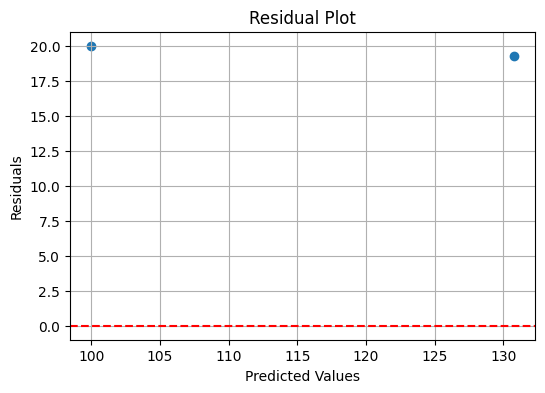

In [226]:
# Q5 – Student Answer

# 1: Create the dataframe
df2 = pd.DataFrame({
    "area_sqft": [800, 1000, 1200, 1500, 1800, 2000],
    "bedrooms": [2,2,3,3,4,4],
    "price": [120, 150, 170, 210, 260, 300]
})
df2

# 2. Split the dataset
X=df2[["area_sqft","bedrooms"]]
y=df2["price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# 3. Fit a LinearRegression model to predict `price` from `area_sqft` and `bedrooms`
model=LinearRegression()
model.fit(X_train,y_train)

# 4. Print model intercept, coefficients, and predictions on the test set.
intercept=model.intercept_
coefficient=model.coef_
y_pred=model.predict(X_test)

print(f"intercept: {intercept:.3f}")
print("coefficient:", coefficient)
print("y_predicted value:", y_pred)
print("y_test values:")
print(y_test, "\n")


# 5. Compute the following metrics on the test set. MAE, RMSE, R2
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mean_squared_error(y_test,y_pred))
r2=r2_score(y_test,y_pred)

print("metrics:")
print("MAE:",mae)
print("RMSE:",rmse)
print("R2:",r2,"\n")

# 6. Plot a residual plot with y_true − y_pred on the vertical axis and y_pred on the horizontal axis.

residuals = y_test - y_pred # here, comparing predicted value with test data value
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

#    - Add a short note explaining what you observe from the residuals.


**Explanation:**

- it has 2 coefficients, one for each numerical feature
- two predicted values for 2 test values.
- for test value 120, predicted value is 100, so residual is 20.
 for test value 150,  predicted value is 130.77, so residual is 19.23.
it can be seen in the residual plot.

In [227]:
# # y=mx+c
# y=0.154 *800+25*2-33.846
# print(y)

# y=0.154 *1000+25*2-33.846
# print(y)

In [228]:
# df2

---

### Q6. Applied Classification, Metrics, Trees and ROC (20 marks)

We start with:

```python
import numpy as np

y_true = np.array([1,0,1,0,1,0,1,0,1,0])
y_prob = np.array([0.9,0.1,0.85,0.2,0.7,0.4,0.6,0.3,0.95,0.05])
```

**Part 1: Threshold based classification and metrics (8 marks)**

1. With threshold **0.5**, convert probabilities to class predictions. Then compute:  
   - Confusion matrix  
   - Precision  
   - Recall  
   - F1 score

2. With threshold **0.3**, convert probabilities to class predictions again and recompute the same metrics.

3. In 3 to 4 sentences, explain how lowering the threshold from 0.5 to 0.3 changed precision and recall and why this happens.

**Part 2: ROC and AUC (6 marks)**

4. Plot the **ROC curve** using `y_true` and `y_prob`.  
5. Compute the **AUC** and print it with 3 decimal places.  
6. Add a one or two line comment on what a high or low AUC means in this context.

**Part 3: Decision Tree on a small dataset (6 marks)**

Create this dataset:

```python
df3 = pd.DataFrame({
    "hours": [1,2,3,4,5,1,2,3,4,5],
    "passed": [0,0,0,1,1,0,0,1,1,1]
})
```

7. Fit a `DecisionTreeClassifier(max_depth=2)` to predict `passed` from `hours`.  
8. Plot the tree using `plot_tree`.  
9. Write 2 to 3 lines explaining whether the tree looks like it might **overfit** or **generalize well**, given the dataset size and the model depth.


**Ans 6.1 to 6.3: Threshold based classification and metrics**

In [229]:
# Q6 – Student Answer

# Part 1: threshold based classification
y_true = np.array([1,0,1,0,1,0,1,0,1,0])
y_prob = np.array([0.9,0.1,0.85,0.2,0.7,0.4,0.6,0.3,0.95,0.05])

# code for threshold 0.5
print("for threshold 0.5")
print("-------------------")

y_pred=(y_prob>=0.5). astype(int)
print("y_pred:",y_pred,"\n")

cm=confusion_matrix(y_true,y_pred)
print("confusion matrix:\n",cm)

precision=precision_score(y_true,y_pred)
print("precision:",precision)

recall=recall_score(y_true,y_pred)
print("recall:",recall)

f1=f1_score(y_true,y_pred)
print("f1 score:",f1)

# code for threshold 0.3
print("\nfor threshold 0.3")
print("-------------------")

y_pred=(y_prob>=0.3). astype(int)
print("y_pred:",y_pred,"\n")

cm=confusion_matrix(y_true,y_pred)
print("confusion matrix:\n",cm)

precision=precision_score(y_true,y_pred)
print("precision:",precision)

recall=recall_score(y_true,y_pred)
print("recall:",recall)

f1=f1_score(y_true,y_pred)
print("f1 score:",f1)


for threshold 0.5
-------------------
y_pred: [1 0 1 0 1 0 1 0 1 0] 

confusion matrix:
 [[5 0]
 [0 5]]
precision: 1.0
recall: 1.0
f1 score: 1.0

for threshold 0.3
-------------------
y_pred: [1 0 1 0 1 1 1 1 1 0] 

confusion matrix:
 [[3 2]
 [0 5]]
precision: 0.7142857142857143
recall: 1.0
f1 score: 0.8333333333333334


**Explanation**

- for threshold 0.5, performance is perfect. all values of precision, recall and f1 score are 1.
- for threshold 0.3, more cases are identified as positive, which has a chance to increase FP.
so precision decreases. it also causes a decrease in the f1 score. so by lowering threshold, the model becomes more generous to catch something as positive.

**Ans 6.4 to 6.6: ROC and AUC**

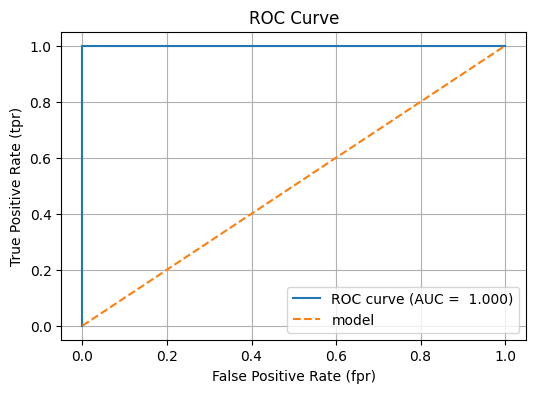

AUC:  1.0


In [230]:
y_true = np.array([1,0,1,0,1,0,1,0,1,0])
y_prob = np.array([0.9,0.1,0.85,0.2,0.7,0.4,0.6,0.3,0.95,0.05])

# Plot the ROC curve using y_true and y_prob.
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc=auc(fpr, tpr)

plt.figure()
plt.plot(fpr,tpr, label=f'ROC curve (AUC = {roc_auc: .3f})')
plt.plot([0,1], [0,1], linestyle='--', label='model')
plt.xlabel('False Positive Rate (fpr)')
plt.ylabel('True Positive Rate (tpr)')
plt.title("ROC Curve")
plt.legend()
plt.show()

# Compute the AUC and print it with 3 decimal places.
print("AUC: ", round(roc_auc, 3))

# Add a one or two line comment on what a high or low AUC means in this context.

**Explanation**

- AUC of 1 means, the models works perfectly in predicting. for very low FPR, it has very high TPR.

**Ans 6.7 to 6.9:  Decision Tree on a small dataset**

Predictions: [1 0]


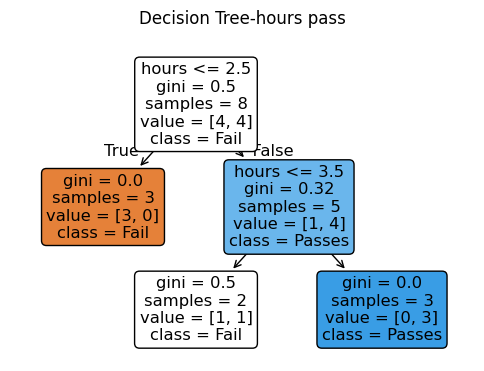

In [231]:
import pandas as pd

df3 = pd.DataFrame({
    "hours": [1,2,3,4,5,1,2,3,4,5],
    "passed": [0,0,0,1,1,0,0,1,1,1]
})

# Fit a DecisionTreeClassifier(max_depth=2) to predict passed from hours.
X=df3[["hours"]]
y=df3["passed"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model=DecisionTreeClassifier(max_depth=2, random_state=42)
model.fit(X_train,y_train)

y_pred = model.predict(X_test)
print("Predictions:", y_pred)

# Plot the tree using plot_tree.
# plt.figure(figsize=(8,6))
plot_tree(
    model,
    feature_names=['hours'],
    class_names = ['Fail','Passes'],
    filled = True,
    rounded = True,
)
plt.title("Decision Tree-hours pass\n")
plt.show()

#### Write 2 to 3 lines explaining whether the tree looks like it might overfit or generalize well, given the dataset size and the model depth.
**Expplanation:**

A Decision Tree with max_depth=2 on such a small dataset has low probability to overfit because the depth is controlled.
As the The model can only create a few simple splits, so i think it generalizes better than a full tree.


**The END**